In [17]:
#Importando paqueterias necesarias.
#
#
#
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Nadam
from tensorflow.keras.callbacks import EarlyStopping
from kerastuner.tuners import RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters
from sklearn.metrics import roc_auc_score, roc_curve, auc
from kerastuner.tuners import GridSearch
from sklearn.model_selection import train_test_split
import shutil
from sklearn.metrics import confusion_matrix




In [5]:
#Cargamos los archivos .h5 de la iniciativa del instituco CERN open data con la funcion h5py.File
#Modificar archivo en uso modificando la ruta hacia los mismos.


filepath1 = '/home/rizz/Downloads/JetNtuple_RunIISummer16_13TeV_MC_1.h5'
filepath2 = '/home/rizz/Downloads/JetNtuple_RunIISummer16_13TeV_MC_10.h5'


h5file1 = h5py.File(filepath1, 'r')
h5file2 = h5py.File(filepath2, 'r')

#Creamos dos objetos tipo dataframe para poder ser modificados con la paqueteria pandas
#En este trabajo se utilizan solamente dos archivos

df1 = pd.DataFrame()
df2 = pd.DataFrame()

#Se convierte el archivo h5 a dataframe.
for key in h5file1.keys():
    df1[key] = h5file1[key]
for key in h5file2.keys():
    df2[key] = h5file2[key]


#Se juntan ambos dataframes.
df = pd.concat([df1, df2], ignore_index=True)


#Se remueven todos los datos que no pertenecen a Gluon (isPhysG==1) o Up,Down o Strange (isPhysUDS==1) y lo convertimos en un solo dataframe llamado df por simplicidad
df = df[(df.isPhysG==1) | (df.isPhysUDS==1)].reset_index()

In [6]:
#Dividimos el arreglo de datos en dos para poder realizar el entrenamiento.
#El 80% son datos de entrenamiento y el 20% son datos de prueba.
train, test = train_test_split(df, test_size=0.2, random_state=42)

train_y = train.isPhysUDS
test_y = test.isPhysUDS

Trial 1 Complete [00h 03m 04s]
val_accuracy: 0.7958868265151977

Best val_accuracy So Far: 0.7958868265151977
Total elapsed time: 00h 03m 04s
Epoch 1/20
419/419 [==============================] - 2s 2ms/step - loss: 0.4610 - accuracy: 0.7916 - val_loss: 0.4599 - val_accuracy: 0.7911
Epoch 2/20
419/419 [==============================] - 1s 2ms/step - loss: 0.4517 - accuracy: 0.7943 - val_loss: 0.4496 - val_accuracy: 0.7959
Epoch 3/20
419/419 [==============================] - 1s 2ms/step - loss: 0.4500 - accuracy: 0.7967 - val_loss: 0.4520 - val_accuracy: 0.7911
Epoch 4/20
419/419 [==============================] - 1s 2ms/step - loss: 0.4494 - accuracy: 0.7964 - val_loss: 0.4499 - val_accuracy: 0.7961
Epoch 5/20
524/524 [==============================] - 0s 523us/step
Random Search Model Summary:
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 256

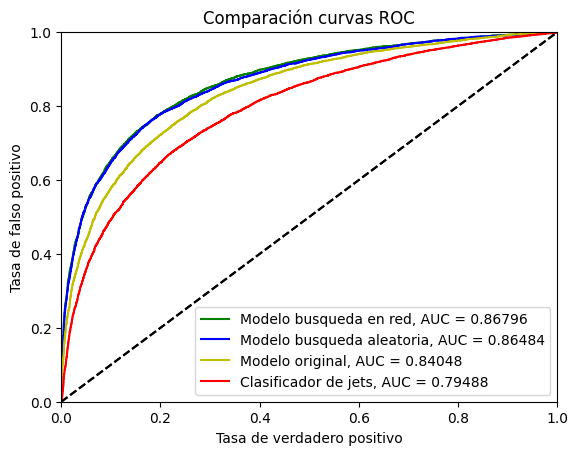

In [14]:
#Definimos las variables de entradas seleccionadas.
input_features = ['jetGirth', 'jetMass', 'jetArea', 'jetPt', 'QG_axis2', 'nGenJetPF', 'jetEta', 'alpha', 'jetPhi', 'QG_mult', 'QG_ptD']

#Numero de pruebas por cada modelo.
trials = 1

#Encontrar la media y la desviacion estandar para cada entrada
train_x_mean = train[input_features].mean()
train_x_std = train[input_features].std()

#Estandarizar variables con media y desviacion estandar
train_x=(train[input_features]-train_x_mean)/train_x_std
test_x=(test[input_features]-train_x_mean)/train_x_std

#Funcion que crea modelos de red neuronal, cumple la funcion del hipermodelo en el tuner de keras para busqueda aleatoria y en red
def build_model(hp):
    model = Sequential()
    model.add(Dense(units=hp.Int('units_input', min_value=32, max_value=256, step=32),
                    kernel_initializer='normal',
                    activation='relu',
                    input_shape=(len(input_features),)))
    model.add(Dropout(0.2))
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(Dense(units=hp.Int('units_' + str(i), min_value=32, max_value=128, step=32),
                        kernel_initializer='normal',
                        activation='relu'))
    model.add(Dense(units=1, kernel_initializer='normal', activation='sigmoid'))
    optimizer = Nadam(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4]))
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

#Busqueda en red de modelos, itera sobre todas las posibilidades
tuner = GridSearch(
    build_model,
    hyperparameters=HyperParameters(),
    tune_new_entries=True,
    allow_new_entries=True,
    objective='val_accuracy',
    max_trials=trials,  
    executions_per_trial=2,
    directory='keras_tuner_dir',
    project_name='simple_dnn_classifier'
)

#Definimos una funcion que evitar el sobrentreno cuando, el parametro de paciencia (Patience) indica que si la perdida de validacion no mejora en 3 iteraciones se detiene
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

#Busqueda de hiperparametros
tuner.search(train_x, train_y, epochs=20, batch_size=128, validation_split=0.2, callbacks=[early_stopping])

#Almacenar los mejores hiperparametros en best_hp
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

#Se contruye modelo en red con los hiperparametros obtenidos
model_grid = tuner.hypermodel.build(best_hp)

#Se entrena el modelo con los mejores hiperparametros y se evalua
model_grid.fit(train_x, train_y, epochs=20, batch_size=128, validation_split=0.2, callbacks=[early_stopping])

test_loss, test_accuracy = model_grid.evaluate(test_x, test_y)

#Se realizan las predicciones sobre los datos de prueba y se grafica la curva ROC con sus tazas de aceptacion.
pred_y_grid = model_grid.predict(test_x)
fpr_grid, tpr_grid, _ = roc_curve(test_y, pred_y_grid)
roc_auc_grid = auc(fpr_grid, tpr_grid)

plt.plot(fpr_grid, tpr_grid, 'g', label='Modelo busqueda en red, AUC = %0.5f' % roc_auc_grid)

#Se muestra el mejor modelo encontrado por la busqueda en red y se almacena en best_model_grid
print("Grid Search Model Summary:")
print(model_grid.summary())

best_model_grid = model_grid

#Se elimina el directorio del tuner para escribir el siguiente
shutil.rmtree('keras_tuner_dir', ignore_errors=True)

#Se defnie el tuner para la busqueda aleatoria con la misma funcion de hipermodelo.
tuner_random = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=trials,  
    executions_per_trial=20,
    directory='keras_tuner_dir',
    project_name='simple_dnn_classifier'
)

#Mismo parametro early stopping que en el modelo en red
early_stopping_random = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

#Se realiza la busqueda aleatoria
tuner_random.search(train_x, train_y, epochs=20, batch_size=128, validation_split=0.2, callbacks=[early_stopping_random])

#Se obtienen los mejores parametros de la busqueda aleatoria
best_hp_random = tuner_random.get_best_hyperparameters(num_trials=1)[0]

#Se contruye el modelo con los mejores hiperparametros
model_random = tuner_random.hypermodel.build(best_hp_random)

#Se entrena el mejor modelo encontrado y se evalua
model_random.fit(train_x, train_y, epochs=20, batch_size=128, validation_split=0.2, callbacks=[early_stopping_random])

test_loss_random, test_accuracy_random = model_random.evaluate(test_x, test_y)

#Predicciones del modelo aleatorio y se grafica su curva ROC sobre la misma grafica para comparacion
pred_y_random = model_random.predict(test_x)
fpr_random, tpr_random, _ = roc_curve(test_y, pred_y_random)
roc_auc_random = auc(fpr_random, tpr_random)

plt.plot(fpr_random, tpr_random, 'b', label='Modelo busqueda aleatoria, AUC = %0.5f' % roc_auc_random)

#Se imprime y almacena la estructura del mejor modelo aleatorio
print("Random Search Model Summary:")
print(model_random.summary())

best_model_random = model_random
###################MODELO EJEMPLO######################################
#Definicion y entrenamiento del modelo preliminar ya incluido en el cuaderno de jupyter.
example_train, example_test = train_test_split(df, test_size=0.2, random_state=42)

example_train_y=example_train.isPhysUDS
example_test_y=example_test.isPhysUDS

#Se usan solamente las variables originales
example_features=['jetPt', 'jetEta', 'QG_mult', 'QG_ptD', 'QG_axis2']

#Se dividen los datos de ejemplo
example_train_x=train[example_features]
example_test_x=test[example_features]

#Estandarizacion de los datos de ejemplo
example_train_x_mean=example_train_x.mean()
example_train_x_std=example_train_x.std()

example_train_x=(example_train_x-example_train_x_mean)/example_train_x_std
example_test_x=(example_test_x-example_train_x_mean)/example_train_x_std

#Se define el modelo de ejemplo
modelex = Sequential()
modelex.add(Dense(100, kernel_initializer='normal', activation='relu', input_dim=example_train_x.shape[1]))
modelex.add(Dropout(0.2))
modelex.add(Dense(100, kernel_initializer='normal', activation='relu'))
modelex.add(Dropout(0.2))
modelex.add(Dense(50, kernel_initializer='normal', activation='relu'))
modelex.add(Dense(1, kernel_initializer='normal', activation='sigmoid'))
modelex.compile(optimizer='Nadam', loss='binary_crossentropy', metrics=['accuracy'])

#Entrenamiento del modelo ejemlo
modelex.fit(example_train_x,
          example_train_y,
          epochs=20,
          batch_size=128,
          validation_split=0.2,
          shuffle=True,
          verbose=1);

#Prediccion y curva ROC sobre la misma grafica para comparacion

example_pred_y = modelex.predict(example_test_x)
example_fpr_dnn, example_tpr_dnn, example_thresholds_dnn  = roc_curve(example_test_y, example_pred_y)
example_roc_auc_dnn = auc(example_fpr_dnn, example_tpr_dnn)
fpr_qgl, tpr_qgl, thresholds_qgl = roc_curve(test_y, test.jetQGl)
roc_auc_qgl = auc(fpr_qgl, tpr_qgl)
##################MODELO EJEMPLO #################################



#Se agregan las curvas ROC del modelo orignial asi como del clasificador de jets
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(example_fpr_dnn, example_tpr_dnn, 'y', label='Modelo original, AUC = %0.5f' % example_roc_auc_dnn)
plt.plot(fpr_qgl, tpr_qgl, 'r', label='Clasificador de jets, AUC = %0.5f'% roc_auc_qgl)


#Se define titulos y subtitulos de la grafica de las curvas ROC
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.legend(loc='lower right')
plt.title("Comparación curvas ROC")
plt.ylabel('Tasa de falso positivo')
plt.xlabel('Tasa de verdadero positivo')
plt.show()



In [15]:
#Se imprimen los mejores modelos encontrados junto con su taza de dropout

#Modelo en red
print(best_model_grid.summary())
print(best_model_random.summary())
print("Dropout values for best_model_grid:")
for layer in best_model_grid.layers:
    if hasattr(layer, 'rate'):
        print(f"{layer.name}: {layer.rate}")

#Modelo aleatorio
print("\nDropout values for best_model_random:")
for layer in best_model_random.layers:
    if hasattr(layer, 'rate'):
        print(f"{layer.name}: {layer.rate}")


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 256)               3072      
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_6 (Dense)             (None, 128)               32896     
                                                                 
 dense_7 (Dense)             (None, 32)                4128      
                                                                 
 dense_8 (Dense)             (None, 1)                 33        
                                                                 
Total params: 40129 (156.75 KB)
Trainable params: 40129 (156.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None
Model: "seq

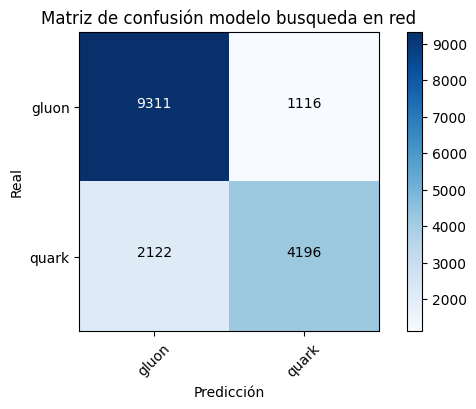

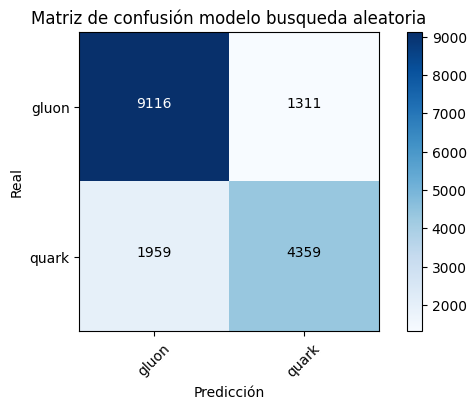

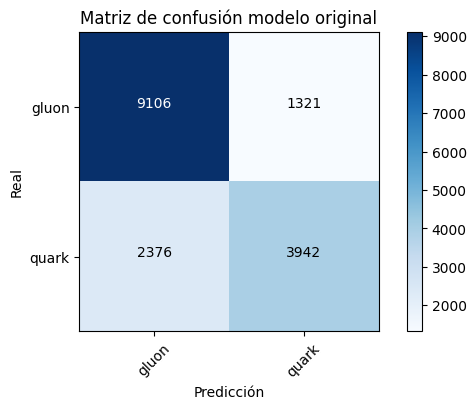

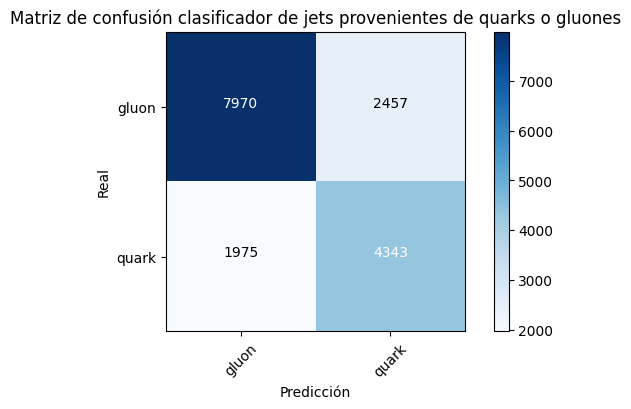

In [18]:
#Funcion para graficar las matrices confusion para los modelos


def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Matriz de confusión {model_name}')
    plt.colorbar()
    tick_marks = np.arange(len(['Negativo', 'Positivo']))
    plt.xticks(tick_marks, ['gluon', 'quark'], rotation=45)
    plt.yticks(tick_marks, ['gluon', 'quark'])
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

#Modelo busqueda en red
plot_confusion_matrix(test_y, pred_y_grid.round(), "modelo busqueda en red")

#Modelo busqueda aleatoria
plot_confusion_matrix(test_y, pred_y_random.round(), "modelo busqueda aleatoria")

#Modelo original
plot_confusion_matrix(example_test_y, example_pred_y.round(), "modelo original")

#Se convierte el el calsificador en un discriminador binario de jets de quarks y gluones y se grafica su matriz confusion
pred_likelihood_discriminator_binary = (test.jetQGl > 0.5).astype(int)

# Plot confusion matrix for the likelihood discriminator
plot_confusion_matrix(test_y, pred_likelihood_discriminator_binary, "clasificador de jets provenientes de quarks o gluones")